📥 Loading dataset...
✅ Loaded 34792 rows


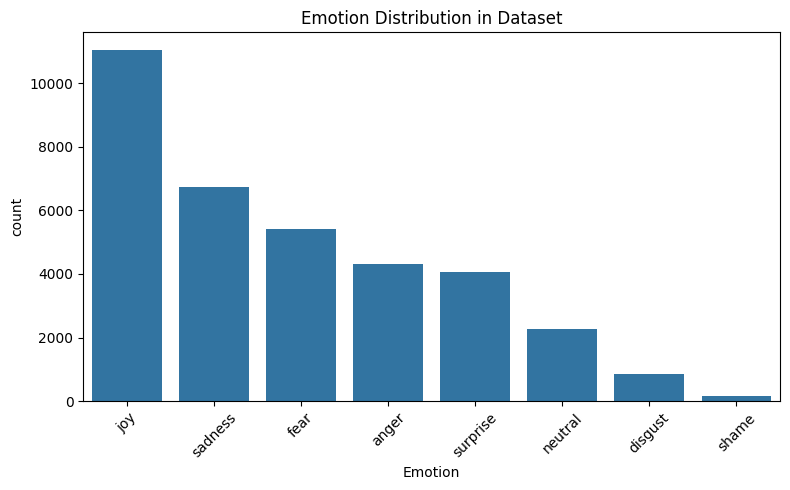

🧹 Cleaning text data...
   Emotion                                               Text  \
0  neutral                                             Why ?    
1      joy    Sage Act upgrade on my to do list for tommorow.   
2  sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...   
3      joy   Such an eye ! The true hazel eye-and so brill...   
4      joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...   

                                          Clean_Text  
0                                                why  
1     sage act upgrade on my to do list for tommorow  
2  on the way to my homegirl baby funeral man i h...  
3  such an eye the true hazel eyeand so brilliant...  
4  ugh babe hugggzzz for u babe naamazed nga ako ...  
⚙️ Training model...

✅ Model trained successfully! Accuracy: 0.613

📊 Classification Report:

              precision    recall  f1-score   support

       anger       0.60      0.54      0.57      1289
     disgust       0.65      0.05      0.09       2

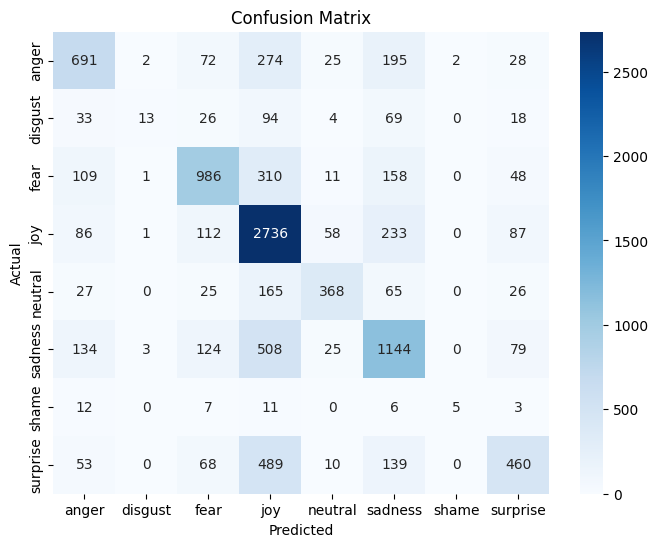

💾 Model saved as text_emotion.pkl

💬 Example Predictions:

💬 Text: I am feeling awesome today!
🎯 Predicted Emotion: joy

💬 Text: This is the worst day ever!
🎯 Predicted Emotion: joy

💬 Text: I can't believe it! That's amazing!
🎯 Predicted Emotion: sadness

💬 Text: I'm so scared about tomorrow...
🎯 Predicted Emotion: fear

💬 Text: Why would you do that to me?!
🎯 Predicted Emotion: anger



In [1]:
# --- Step 1: Import Required Libraries ---
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# --- Step 2: Load Dataset ---
print("📥 Loading dataset...")
df = pd.read_csv("emotion_dataset.csv")
print(f"✅ Loaded {len(df)} rows")

# --- Step 3: Visualize Data ---
plt.figure(figsize=(8,5))
sns.countplot(x='Emotion', data=df, order=df['Emotion'].value_counts().index)
plt.title('Emotion Distribution in Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Step 4: Clean Text Function ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)         # remove @mentions
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

print("🧹 Cleaning text data...")
df['Clean_Text'] = df['Text'].apply(clean_text)
print(df.head())

# --- Step 5: Split Data ---
X = df['Clean_Text']
y = df['Emotion']
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Step 6: Build Model Pipeline ---
print("⚙️ Training model...")
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('lr', LogisticRegression(max_iter=400))
])

pipe_lr.fit(x_train, y_train)

# --- Step 7: Evaluate Model ---
acc = pipe_lr.score(x_test, y_test)
print(f"\n✅ Model trained successfully! Accuracy: {acc:.3f}\n")

y_pred = pipe_lr.predict(x_test)
print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# --- Step 8: Confusion Matrix ---
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred, labels=pipe_lr.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=pipe_lr.classes_, yticklabels=pipe_lr.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- Step 9: Save Model ---
joblib.dump(pipe_lr, "text_emotion.pkl")
print("💾 Model saved as text_emotion.pkl")

# --- Step 10: Prediction Function ---
def predict_emotion(text):
    text_clean = clean_text(text)
    pred = pipe_lr.predict([text_clean])[0]
    return pred

# --- Step 11: Try Example Predictions ---
print("\n💬 Example Predictions:\n")
examples = [
    "I am feeling awesome today!",
    "This is the worst day ever!",
    "I can't believe it! That's amazing!",
    "I'm so scared about tomorrow...",
    "Why would you do that to me?!"
]

for ex in examples:
    print(f"💬 Text: {ex}")
    print(f"🎯 Predicted Emotion: {predict_emotion(ex)}\n")
